In [ ]:
# Cell 1: mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

MessageError: Error: credential propagation was unsuccessful

In [ ]:
# Cell 2
file_path = "/content/drive/MyDrive/RAIM_Project_v2/run_plos_only/matrices/sequences_patient_level.pkl"

In [ ]:
# Cell 3: load and inspect the pickle
import pickle

file_path = "/content/drive/MyDrive/RAIM_Project_v2/run_plos_only/matrices/sequences_patient_level.pkl"
with open(file_path, "rb") as f:
    data = pickle.load(f)

print(type(data))

if isinstance(data, dict):
    keys = list(data.keys())
    print("num keys:", len(keys))
    print("sample keys:", keys[:5])
    first = data[keys[0]]
    print("type of value:", type(first))
    print("shape/len of value:", getattr(first, 'shape', len(first)))
    print(first)
elif isinstance(data, list):
    print("num items:", len(data))
    print("type of item 0:", type(data[0]))
    print(data[0])
else:
    print(data)

<class 'dict'>
num keys: 36
sample keys: ['05a10115-281a-d838-bdfd-8901fe031c41', '11eecaea-e92a-678f-801a-eabfe17859d9', '16c98be5-64d7-aa61-9666-c4136b0e9fa6', '1b0f7602-97a1-dea6-f2a2-a46ab3c82437', '3f8092e4-a679-1595-f0de-bbae353d1310']
type of value: <class 'dict'>
shape/len of value: 4
{'X': array([[ 4.50000000e+01,  1.00000000e+00,  2.00000000e+00,
         1.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  4.50488087e-03, -3.28997336e-03,
        -3.14422883e-03,  2.55259313e-03, -5.00221271e-03,
         5.87061327e-03,  3.58006638e-03,  3.43948882e-03,
        -4.55851853e-03,  6.09346759e-03, -6.93157129e-03,
         6.76584430e-03, -4.63610981e-03, -1.43136177e-03,
        -2.17792578e-03, -5.46901487e-04, -3.55372392e-03,
        -1.20192301e-03,  4.98897489e-03, -5.21772821e-03,
         5.42138238e-03, -1.27038080e-03,  1.39693636e-03,
         1.39797013e-03, -6.34489767e-03,  3.009436

In [ ]:
# Cell 4: imports for model
import torch
import torch.nn as nn
import torch.nn.functional as F

In [ ]:
# Cell 5: RAIM model class (rebuilt for CarePathways — regression output only, per-timestep predictions)
class RAIMModel(nn.Module):
    """
    RAIM with attention, rebuilt for the CarePathways pipeline.
    Input: (batch, max_len, 524) padded per-patient encounter sequences.
    Output: (batch, max_len) continuous LOS prediction, one per encounter timestep.
    """
    def __init__(self, input_dim=524, hidden_size=200, max_len=20):
        super().__init__()
        self.input_dim = input_dim
        self.hidden_size = hidden_size
        self.max_len = max_len

        # attention scoring
        self.mlp_for_x = nn.Linear(input_dim, 1, bias=False)
        self.mlp_for_hidden = nn.Linear(hidden_size, max_len, bias=True)

        # recurrent update
        self.grucell = nn.GRUCell(input_dim, hidden_size)

        # regression head — single linear output, no activation
        self.output_head = nn.Linear(hidden_size, 1)

    def forward(self, x, lengths):
        """
        x: (batch, max_len, input_dim) — padded sequences
        lengths: (batch,) — actual number of encounters per patient
        """
        batch_size = x.size(0)
        device = x.device
        hidden = torch.zeros(batch_size, self.hidden_size, device=device)  # reset every call

        outputs = []  # will hold one (batch,) prediction per timestep

        for t in range(self.max_len):
            active = (lengths > t).float().unsqueeze(1)  # (batch, 1)

            prefix = x[:, :t + 1, :]                       # (batch, t+1, input_dim)
            x_energy = self.mlp_for_x(prefix).squeeze(-1)  # (batch, t+1)
            h_energy = self.mlp_for_hidden(hidden)[:, :t + 1]  # (batch, t+1)
            energy = x_energy + h_energy
            attn_weights = F.softmax(energy, dim=1)        # (batch, t+1)

            context = torch.sum(prefix * attn_weights.unsqueeze(-1), dim=1)  # (batch, input_dim)

            new_hidden = self.grucell(context, hidden)
            hidden = active * new_hidden + (1 - active) * hidden  # freeze if past this patient's length

            pred_t = self.output_head(hidden).squeeze(-1)  # (batch,) prediction using hidden AT this timestep
            outputs.append(pred_t)

        out = torch.stack(outputs, dim=1)  # (batch, max_len)
        return out

In [ ]:
# Cell 6: smoke test on dummy data — run before touching real data
model = RAIMModel(input_dim=524, hidden_size=200, max_len=20)

dummy_x = torch.randn(8, 20, 524)          # batch of 8, padded to 20 steps
dummy_lengths = torch.tensor([5, 12, 20, 3, 8, 1, 15, 9])

out = model(dummy_x, dummy_lengths)
print(out.shape)   # expect torch.Size([8, 20])
print(out[0])

torch.Size([8, 20])
tensor([ 0.0438, -0.1319, -0.0857, -0.1581, -0.1905, -0.1905, -0.1905, -0.1905,
        -0.1905, -0.1905, -0.1905, -0.1905, -0.1905, -0.1905, -0.1905, -0.1905,
        -0.1905, -0.1905, -0.1905, -0.1905], grad_fn=<SelectBackward0>)


In [ ]:
# Cell 7: check n_encounters distribution to pick max_len
import numpy as np

n_encounters_list = [v["n_encounters"] for v in data.values()]
n_encounters_arr = np.array(n_encounters_list)

print("num patients:", len(data))
print("min:", n_encounters_arr.min())
print("max:", n_encounters_arr.max())
print("mean:", n_encounters_arr.mean())
print("median:", np.median(n_encounters_arr))
print("95th percentile:", np.percentile(n_encounters_arr, 95))
print("99th percentile:", np.percentile(n_encounters_arr, 99))

num patients: 36
min: 1
max: 2
mean: 1.0277777777777777
median: 1.0
95th percentile: 1.0
99th percentile: 1.6499999999999986


In [ ]:
# Cell 8: build padded tensors for all patients
MAX_LEN = int(np.percentile(n_encounters_arr, 99))  # adjust after seeing Cell 7 output
INPUT_DIM = 524

patient_ids = list(data.keys())
num_patients = len(patient_ids)

X_padded = np.zeros((num_patients, MAX_LEN, INPUT_DIM), dtype=np.float32)
Y_padded = np.zeros((num_patients, MAX_LEN), dtype=np.float32)
lengths = np.zeros((num_patients,), dtype=np.int64)

dropped_patients = []

for i, pid in enumerate(patient_ids):
    entry = data[pid]
    n = entry["n_encounters"]
    x = entry["X"]  # (n_encounters, 524)
    y = entry["Y"]  # (n_encounters,)

    if n > MAX_LEN:
        dropped_patients.append((pid, n))
        n = MAX_LEN
        x = x[:MAX_LEN]
        y = y[:MAX_LEN]

    X_padded[i, :n, :] = x
    Y_padded[i, :n] = y
    lengths[i] = n

print("X_padded shape:", X_padded.shape)
print("Y_padded shape:", Y_padded.shape)
print("lengths shape:", lengths.shape)
print("patients truncated to MAX_LEN:", len(dropped_patients))

X_padded shape: (36, 1, 524)
Y_padded shape: (36, 1)
lengths shape: (36,)
patients truncated to MAX_LEN: 1


In [ ]:
# Cell 8b — run in mixed run notebook (run_05_age_med_years_med)
import pickle
import numpy as np

LLOS_THRESHOLD = 14.96

with open("/content/drive/MyDrive/RAIM_Project_v2/run_05_age_med_years_med/matrices/sequences_patient_level.pkl", "rb") as f:
    data_mixed = pickle.load(f)

all_plos_patients = 0
mixed_patients = 0

for pid, entry in data_mixed.items():
    y = entry["Y"]
    if (y > LLOS_THRESHOLD).all():
        all_plos_patients += 1
    else:
        mixed_patients += 1

print(f"Patients where ALL encounters are PLOS (>14.96): {all_plos_patients}")
print(f"Patients with MIXED encounters (some short, some long): {mixed_patients}")
print(f"Total: {all_plos_patients + mixed_patients}")

Patients where ALL encounters are PLOS (>14.96): 36
Patients with MIXED encounters (some short, some long): 273
Total: 309


In [ ]:
# Cell 9: Dataset and DataLoader
from torch.utils.data import Dataset, DataLoader

class PatientSequenceDataset(Dataset):
    def __init__(self, X_padded, Y_padded, lengths):
        self.X = torch.tensor(X_padded, dtype=torch.float32)
        self.Y = torch.tensor(Y_padded, dtype=torch.float32)
        self.lengths = torch.tensor(lengths, dtype=torch.long)

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx):
        return self.X[idx], self.Y[idx], self.lengths[idx]

dataset = PatientSequenceDataset(X_padded, Y_padded, lengths)
loader = DataLoader(dataset, batch_size=32, shuffle=True)

xb, yb, lb = next(iter(loader))
print(xb.shape, yb.shape, lb.shape)

torch.Size([32, 1, 524]) torch.Size([32, 1]) torch.Size([32])


In [ ]:
# Cell 10: patient-level train/val split
from sklearn.model_selection import train_test_split

indices = np.arange(num_patients)
train_idx, val_idx = train_test_split(indices, test_size=0.2, random_state=42)

train_dataset = torch.utils.data.Subset(dataset, train_idx)
val_dataset = torch.utils.data.Subset(dataset, val_idx)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

print(f"train: {len(train_dataset)} patients, val: {len(val_dataset)} patients")

train: 28 patients, val: 8 patients


In [ ]:
# Cell 11: masked MSE loss — ignores zero-padded timesteps beyond each patient's real length
def masked_mse(pred, target, lengths):
    max_len = pred.size(1)
    mask = (torch.arange(max_len, device=pred.device).unsqueeze(0) < lengths.unsqueeze(1)).float()
    diff2 = (pred - target) ** 2 * mask
    return diff2.sum() / mask.sum()

In [ ]:
# Cell 12: training loop
def train_model(model, train_loader, val_loader, max_epochs=100, patience=10, lr=1e-3, device='cpu'):
    model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    best_val_loss = float('inf')
    best_state = None
    epochs_no_improve = 0
    history = {'train_mse': [], 'val_mse': [], 'val_rmse': []}

    for epoch in range(1, max_epochs + 1):
        model.train()
        train_loss_sum, train_count = 0.0, 0
        for xb, yb, lb in train_loader:
            xb, yb, lb = xb.to(device), yb.to(device), lb.to(device)
            optimizer.zero_grad()
            pred = model(xb, lb)
            loss = masked_mse(pred, yb, lb)
            loss.backward()
            optimizer.step()
            train_loss_sum += loss.item() * xb.size(0)
            train_count += xb.size(0)
        train_mse = train_loss_sum / train_count

        model.eval()
        val_loss_sum, val_count = 0.0, 0
        with torch.no_grad():
            for xb, yb, lb in val_loader:
                xb, yb, lb = xb.to(device), yb.to(device), lb.to(device)
                pred = model(xb, lb)
                loss = masked_mse(pred, yb, lb)
                val_loss_sum += loss.item() * xb.size(0)
                val_count += xb.size(0)
        val_mse = val_loss_sum / val_count
        val_rmse = val_mse ** 0.5

        history['train_mse'].append(train_mse)
        history['val_mse'].append(val_mse)
        history['val_rmse'].append(val_rmse)
        print(f"epoch {epoch}: train_mse={train_mse:.4f} val_mse={val_mse:.4f} val_rmse={val_rmse:.4f}")

        if val_mse < best_val_loss:
            best_val_loss = val_mse
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f"early stopping at epoch {epoch} (no improvement for {patience} epochs)")
                break

    model.load_state_dict(best_state)
    return model, history, best_val_loss

In [ ]:
# Cell 13: Case 3 training run — full dataset, no filtering
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = RAIMModel(input_dim=524, hidden_size=200, max_len=MAX_LEN)

model, history, best_val_mse = train_model(
    model, train_loader, val_loader, max_epochs=100, patience=10, lr=1e-3, device=device
)

print(f"best val MSE: {best_val_mse:.4f}, best val RMSE: {best_val_mse**0.5:.4f}")

epoch 1: train_mse=602.9276 val_mse=1078.5083 val_rmse=32.8407
epoch 2: train_mse=592.6974 val_mse=1065.8726 val_rmse=32.6477
epoch 3: train_mse=582.5942 val_mse=1053.4515 val_rmse=32.4569
epoch 4: train_mse=572.6345 val_mse=1041.2649 val_rmse=32.2686
epoch 5: train_mse=562.8315 val_mse=1029.3173 val_rmse=32.0830
epoch 6: train_mse=553.1926 val_mse=1017.6108 val_rmse=31.9000
epoch 7: train_mse=543.7250 val_mse=1006.1436 val_rmse=31.7198
epoch 8: train_mse=534.4343 val_mse=994.9096 val_rmse=31.5422
epoch 9: train_mse=525.3230 val_mse=983.8979 val_rmse=31.3671
epoch 10: train_mse=516.3907 val_mse=973.0948 val_rmse=31.1945
epoch 11: train_mse=507.6347 val_mse=962.4832 val_rmse=31.0239
epoch 12: train_mse=499.0498 val_mse=952.0435 val_rmse=30.8552
epoch 13: train_mse=490.6293 val_mse=941.7557 val_rmse=30.6880
epoch 14: train_mse=482.3645 val_mse=931.6000 val_rmse=30.5221
epoch 15: train_mse=474.2455 val_mse=921.5579 val_rmse=30.3572
epoch 16: train_mse=466.2611 val_mse=911.6140 val_rmse=30

In [ ]:
# Cell 14: sanity check per Haimonti — 5000-epoch run with Drive checkpointing every 500 epochs, resumable
import os

CHECKPOINT_PATH = "/content/drive/MyDrive/RAIM_Project_v2/checkpoints/pure_plos_sanity_5000ep.pt"
os.makedirs(os.path.dirname(CHECKPOINT_PATH), exist_ok=True)

def train_model_resumable(model, train_loader, val_loader, max_epochs=5000, patience=500,
                           lr=1e-3, device='cpu', checkpoint_path=None, checkpoint_every=500):
    model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    start_epoch = 1
    best_val_loss = float('inf')
    best_state = None
    epochs_no_improve = 0
    history = {'train_mse': [], 'val_mse': [], 'val_rmse': []}

    if checkpoint_path and os.path.exists(checkpoint_path):
        ckpt = torch.load(checkpoint_path, map_location=device)
        model.load_state_dict(ckpt['model_state'])
        optimizer.load_state_dict(ckpt['optimizer_state'])
        start_epoch = ckpt['epoch'] + 1
        best_val_loss = ckpt['best_val_loss']
        best_state = ckpt['best_state']
        epochs_no_improve = ckpt['epochs_no_improve']
        history = ckpt['history']
        print(f"resuming from checkpoint at epoch {ckpt['epoch']} (best_val_loss={best_val_loss:.4f})")

    for epoch in range(start_epoch, max_epochs + 1):
        model.train()
        train_loss_sum, train_count = 0.0, 0
        for xb, yb, lb in train_loader:
            xb, yb, lb = xb.to(device), yb.to(device), lb.to(device)
            optimizer.zero_grad()
            pred = model(xb, lb)
            loss = masked_mse(pred, yb, lb)
            loss.backward()
            optimizer.step()
            train_loss_sum += loss.item() * xb.size(0)
            train_count += xb.size(0)
        train_mse = train_loss_sum / train_count

        model.eval()
        val_loss_sum, val_count = 0.0, 0
        with torch.no_grad():
            for xb, yb, lb in val_loader:
                xb, yb, lb = xb.to(device), yb.to(device), lb.to(device)
                pred = model(xb, lb)
                loss = masked_mse(pred, yb, lb)
                val_loss_sum += loss.item() * xb.size(0)
                val_count += xb.size(0)
        val_mse = val_loss_sum / val_count
        val_rmse = val_mse ** 0.5

        history['train_mse'].append(train_mse)
        history['val_mse'].append(val_mse)
        history['val_rmse'].append(val_rmse)
        print(f"epoch {epoch}: train_mse={train_mse:.4f} val_mse={val_mse:.4f} val_rmse={val_rmse:.4f}")

        improved = val_mse < best_val_loss
        if improved:
            best_val_loss = val_mse
            best_state = {k: v.clone().cpu() for k, v in model.state_dict().items()}
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        if checkpoint_path and (epoch % checkpoint_every == 0 or epoch == max_epochs):
            torch.save({
                'epoch': epoch,
                'model_state': model.state_dict(),
                'optimizer_state': optimizer.state_dict(),
                'best_val_loss': best_val_loss,
                'best_state': best_state,
                'epochs_no_improve': epochs_no_improve,
                'history': history,
            }, checkpoint_path)
            print(f"  [checkpoint saved at epoch {epoch}]")

        if epochs_no_improve >= patience:
            print(f"early stopping at epoch {epoch} (no improvement for {patience} epochs)")
            if checkpoint_path:
                torch.save({
                    'epoch': epoch, 'model_state': model.state_dict(),
                    'optimizer_state': optimizer.state_dict(), 'best_val_loss': best_val_loss,
                    'best_state': best_state, 'epochs_no_improve': epochs_no_improve, 'history': history,
                }, checkpoint_path)
            break

    model.load_state_dict(best_state)
    return model, history, best_val_loss

device = 'cuda' if torch.cuda.is_available() else 'cpu'
model_sanity = RAIMModel(input_dim=524, hidden_size=200, max_len=MAX_LEN)

model_sanity, history_sanity, best_val_mse_sanity = train_model_resumable(
    model_sanity, train_loader, val_loader, max_epochs=5000, patience=500, lr=1e-3,
    device=device, checkpoint_path=CHECKPOINT_PATH, checkpoint_every=500
)

print(f"[100-epoch run, patience 10]    best val RMSE: {best_val_mse**0.5:.4f}")
print(f"[5000-epoch run, patience 500]  best val RMSE: {best_val_mse_sanity**0.5:.4f}")
print(f"5000-run stopped at epoch: {len(history_sanity['val_mse'])}")

resuming from checkpoint at epoch 732 (best_val_loss=300.6819)
epoch 733: train_mse=5.2536 val_mse=327.5484 val_rmse=18.0983
early stopping at epoch 733 (no improvement for 500 epochs)
[100-epoch run, patience 10]    best val RMSE: 19.2513
[5000-epoch run, patience 500]  best val RMSE: 17.3402
5000-run stopped at epoch: 733


In [ ]:
# Cell 15: masked MSE with an optional LOS-threshold filter, for Cases 1 and 2
LLOS_THRESHOLD = 14.96  # mean + 2*std, same cutoff used to define the cohort in preprocessing

def masked_mse_filtered(pred, target, lengths, threshold=None):
    max_len = pred.size(1)
    real_mask = (torch.arange(max_len, device=pred.device).unsqueeze(0) < lengths.unsqueeze(1)).float()
    if threshold is not None:
        long_mask = (target > threshold).float()
        real_mask = real_mask * long_mask
    diff2 = (pred - target) ** 2 * real_mask
    denom = real_mask.sum()
    if denom == 0:
        return torch.zeros((), device=pred.device, requires_grad=True)
    return diff2.sum() / denom

In [ ]:
# Cell 16: diagnostic — how many encounters actually exceed the LLOS threshold
train_long_count, train_total = 0, 0
val_long_count, val_total = 0, 0

for xb, yb, lb in train_loader:
    mask = torch.arange(yb.size(1)).unsqueeze(0) < lb.unsqueeze(1)
    train_total += mask.sum().item()
    train_long_count += ((yb > LLOS_THRESHOLD) & mask).sum().item()

for xb, yb, lb in val_loader:
    mask = torch.arange(yb.size(1)).unsqueeze(0) < lb.unsqueeze(1)
    val_total += mask.sum().item()
    val_long_count += ((yb > LLOS_THRESHOLD) & mask).sum().item()

print(f"train: {train_long_count} / {train_total} encounters exceed {LLOS_THRESHOLD} days ({100*train_long_count/train_total:.1f}%)")
print(f"val:   {val_long_count} / {val_total} encounters exceed {LLOS_THRESHOLD} days ({100*val_long_count/val_total:.1f}%)")

train: 28 / 28 encounters exceed 14.96 days (100.0%)
val:   8 / 8 encounters exceed 14.96 days (100.0%)


In [ ]:
# Cell 16b — compute exact encounter counts for Cases 1, 2, 3 comparison table
import numpy as np

LLOS_THRESHOLD = 14.96

# Train and val patient counts
print(f"Train patients: {len(train_idx)}")
print(f"Val patients:   {len(val_idx)}")

# Case 3: all encounters, both splits
train_total_enc = sum(lengths[i] for i in train_idx)
val_total_enc   = sum(lengths[i] for i in val_idx)
print(f"\nCase 3 (all encounters):")
print(f"  Train: {train_total_enc} encounters, Val: {val_total_enc} encounters")

# Case 1 and Case 2: count PLOS encounters (LOS > threshold) per split
train_plos_enc = sum(
    int((Y_padded[i, :lengths[i]] > LLOS_THRESHOLD).sum())
    for i in train_idx
)
val_plos_enc = sum(
    int((Y_padded[i, :lengths[i]] > LLOS_THRESHOLD).sum())
    for i in val_idx
)
print(f"\nCase 1 (train PLOS-only, eval PLOS-only):")
print(f"  Train: {train_plos_enc} PLOS encounters, Val: {val_plos_enc} PLOS encounters")

print(f"\nCase 2 (train all, eval PLOS-only):")
print(f"  Train: {train_total_enc} encounters (all), Val: {val_plos_enc} PLOS encounters")

# Also compute pure-PLOS LOS stats from Y_padded (all patients)
all_plos_los = []
for pid in range(num_patients):
    for t in range(lengths[pid]):
        y = Y_padded[pid, t]
        if y > LLOS_THRESHOLD:
            all_plos_los.append(y)
all_plos_los = np.array(all_plos_los)
print(f"\nPure PLOS subset (all patients, LOS > {LLOS_THRESHOLD}):")
print(f"  Encounters: {len(all_plos_los)}")
print(f"  Mean LOS:   {all_plos_los.mean():.2f}")
print(f"  Median LOS: {np.median(all_plos_los):.2f}")
print(f"  Std:        {all_plos_los.std():.2f}")
print(f"  Min:        {all_plos_los.min():.2f}")
print(f"  Max:        {all_plos_los.max():.2f}")

# Patients represented in pure PLOS
plos_patients = sum(1 for i in range(num_patients) if (Y_padded[i, :lengths[i]] > LLOS_THRESHOLD).any())
print(f"  Patients with >=1 PLOS encounter: {plos_patients}")

Train patients: 28
Val patients:   8

Case 3 (all encounters):
  Train: 28 encounters, Val: 8 encounters

Case 1 (train PLOS-only, eval PLOS-only):
  Train: 28 PLOS encounters, Val: 8 PLOS encounters

Case 2 (train all, eval PLOS-only):
  Train: 28 encounters (all), Val: 8 PLOS encounters

Pure PLOS subset (all patients, LOS > 14.96):
  Encounters: 36
  Mean LOS:   23.97
  Median LOS: 19.50
  Std:        10.89
  Min:        15.00
  Max:        68.00
  Patients with >=1 PLOS encounter: 36


In [ ]:
# Cell 17: generalized training loop for Cases 1-3 — train_threshold/eval_threshold=None means "all encounters" (Case 3 behavior)
def train_model_case(model, train_loader, val_loader, max_epochs=100, patience=10, lr=1e-3,
                      device='cpu', train_threshold=None, eval_threshold=None):
    model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    best_val_loss = float('inf')
    best_state = None
    epochs_no_improve = 0
    history = {'train_mse': [], 'val_mse': [], 'val_rmse': []}

    for epoch in range(1, max_epochs + 1):
        model.train()
        train_loss_sum, train_count = 0.0, 0
        for xb, yb, lb in train_loader:
            xb, yb, lb = xb.to(device), yb.to(device), lb.to(device)
            optimizer.zero_grad()
            pred = model(xb, lb)
            loss = masked_mse_filtered(pred, yb, lb, threshold=train_threshold)
            loss.backward()
            optimizer.step()
            train_loss_sum += loss.item() * xb.size(0)
            train_count += xb.size(0)
        train_mse = train_loss_sum / train_count

        model.eval()
        val_loss_sum, val_count = 0.0, 0
        with torch.no_grad():
            for xb, yb, lb in val_loader:
                xb, yb, lb = xb.to(device), yb.to(device), lb.to(device)
                pred = model(xb, lb)
                loss = masked_mse_filtered(pred, yb, lb, threshold=eval_threshold)
                val_loss_sum += loss.item() * xb.size(0)
                val_count += xb.size(0)
        val_mse = val_loss_sum / val_count
        val_rmse = val_mse ** 0.5

        history['train_mse'].append(train_mse)
        history['val_mse'].append(val_mse)
        history['val_rmse'].append(val_rmse)
        print(f"epoch {epoch}: train_mse={train_mse:.4f} val_mse={val_mse:.4f} val_rmse={val_rmse:.4f}")

        if val_mse < best_val_loss:
            best_val_loss = val_mse
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f"early stopping at epoch {epoch} (no improvement for {patience} epochs)")
                break

    model.load_state_dict(best_state)
    return model, history, best_val_loss

In [ ]:
# Cell 18: Case 1 — threshold at mean+2*std, train and evaluate only on long-LOS encounters
model_case1 = RAIMModel(input_dim=524, hidden_size=200, max_len=MAX_LEN)

model_case1, history_case1, best_val_mse_case1 = train_model_case(
    model_case1, train_loader, val_loader, max_epochs=100, patience=10, lr=1e-3,
    device=device, train_threshold=LLOS_THRESHOLD, eval_threshold=LLOS_THRESHOLD
)

print(f"[Case 1] best val MSE: {best_val_mse_case1:.4f}, best val RMSE: {best_val_mse_case1**0.5:.4f}")

epoch 1: train_mse=577.9504 val_mse=1050.0183 val_rmse=32.4040
epoch 2: train_mse=568.7044 val_mse=1038.9022 val_rmse=32.2320
epoch 3: train_mse=559.5867 val_mse=1027.9594 val_rmse=32.0618
epoch 4: train_mse=550.6025 val_mse=1017.1902 val_rmse=31.8934
epoch 5: train_mse=541.7511 val_mse=1006.5854 val_rmse=31.7267
epoch 6: train_mse=533.0257 val_mse=996.1317 val_rmse=31.5616
epoch 7: train_mse=524.4167 val_mse=985.8162 val_rmse=31.3977
epoch 8: train_mse=515.9142 val_mse=975.6250 val_rmse=31.2350
epoch 9: train_mse=507.5086 val_mse=965.5420 val_rmse=31.0732
epoch 10: train_mse=499.1906 val_mse=955.5490 val_rmse=30.9120
epoch 11: train_mse=490.9530 val_mse=945.6267 val_rmse=30.7510
epoch 12: train_mse=482.7903 val_mse=935.7571 val_rmse=30.5901
epoch 13: train_mse=474.6989 val_mse=925.9258 val_rmse=30.4290
epoch 14: train_mse=466.6765 val_mse=916.1232 val_rmse=30.2675
epoch 15: train_mse=458.7220 val_mse=906.3429 val_rmse=30.1055
epoch 16: train_mse=450.8335 val_mse=896.5793 val_rmse=29.9

In [ ]:
# Cell 19: Case 2 — train on all encounters, evaluate only on prolonged-LOS encounters
model_case2 = RAIMModel(input_dim=524, hidden_size=200, max_len=MAX_LEN)

model_case2, history_case2, best_val_mse_case2 = train_model_case(
    model_case2, train_loader, val_loader, max_epochs=100, patience=10, lr=1e-3,
    device=device, train_threshold=None, eval_threshold=LLOS_THRESHOLD
)

print(f"[Case 2] best val MSE: {best_val_mse_case2:.4f}, best val RMSE: {best_val_mse_case2**0.5:.4f}")

epoch 1: train_mse=585.0260 val_mse=1058.7463 val_rmse=32.5384
epoch 2: train_mse=575.1254 val_mse=1046.7148 val_rmse=32.3530
epoch 3: train_mse=565.2950 val_mse=1034.7314 val_rmse=32.1672
epoch 4: train_mse=555.5288 val_mse=1022.7900 val_rmse=31.9811
epoch 5: train_mse=545.8205 val_mse=1010.8734 val_rmse=31.7942
epoch 6: train_mse=536.1633 val_mse=998.9698 val_rmse=31.6065
epoch 7: train_mse=526.5540 val_mse=987.0790 val_rmse=31.4178
epoch 8: train_mse=516.9960 val_mse=975.2106 val_rmse=31.2284
epoch 9: train_mse=507.4976 val_mse=963.3790 val_rmse=31.0383
epoch 10: train_mse=498.0691 val_mse=951.6021 val_rmse=30.8480
epoch 11: train_mse=488.7218 val_mse=939.8982 val_rmse=30.6578
epoch 12: train_mse=479.4671 val_mse=928.2824 val_rmse=30.4677
epoch 13: train_mse=470.3150 val_mse=916.7648 val_rmse=30.2781
epoch 14: train_mse=461.2720 val_mse=905.3505 val_rmse=30.0890
epoch 15: train_mse=452.3399 val_mse=894.0400 val_rmse=29.9005
epoch 16: train_mse=443.5176 val_mse=882.8320 val_rmse=29.7

In [ ]:
# Cell 20: extract (true, predicted) pairs from a trained model, honoring each case's mask
def get_predictions(model, loader, device, threshold=None):
    model.eval()
    all_true, all_pred = [], []
    with torch.no_grad():
        for xb, yb, lb in loader:
            xb, yb, lb = xb.to(device), yb.to(device), lb.to(device)
            pred = model(xb, lb)
            max_len = pred.size(1)
            mask = torch.arange(max_len, device=device).unsqueeze(0) < lb.unsqueeze(1)
            if threshold is not None:
                mask = mask & (yb > threshold)
            all_true.append(yb[mask].cpu().numpy())
            all_pred.append(pred[mask].cpu().numpy())
    return np.concatenate(all_true), np.concatenate(all_pred)

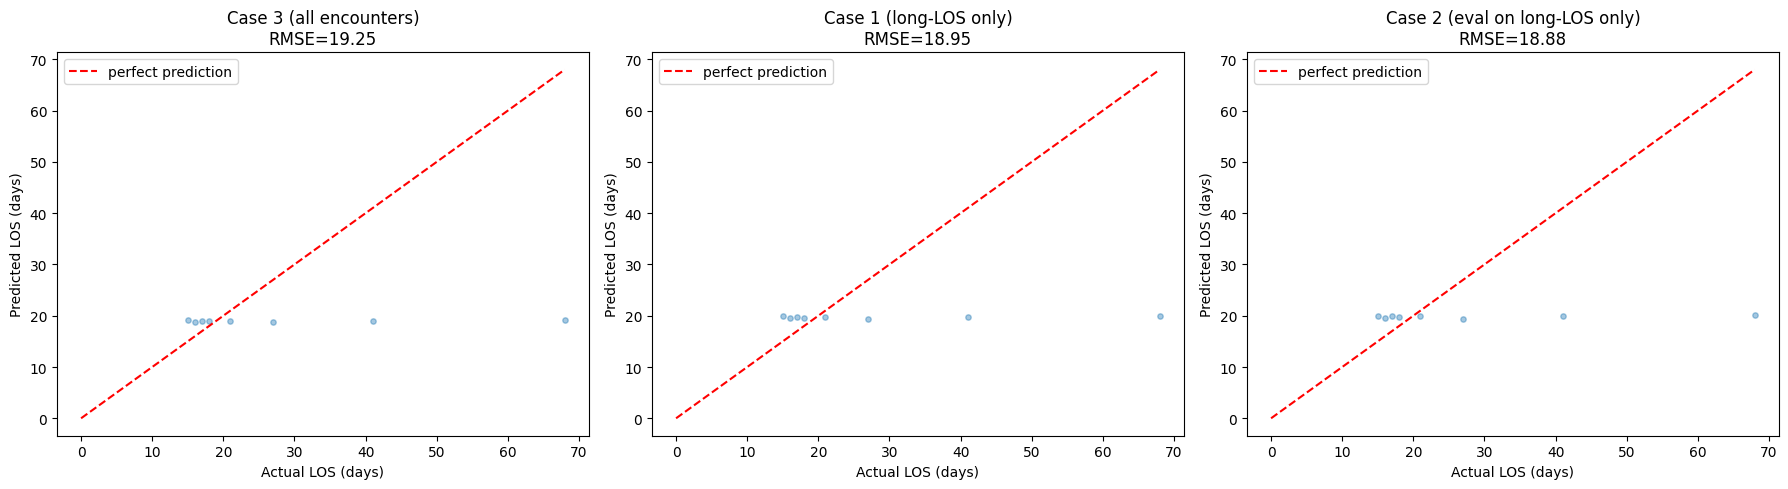

In [ ]:
# Cell 21: actual vs predicted scatter for Case 3, Case 1, Case 2
import matplotlib.pyplot as plt

true3, pred3 = get_predictions(model, val_loader, device, threshold=None)
true1, pred1 = get_predictions(model_case1, val_loader, device, threshold=LLOS_THRESHOLD)
true2, pred2 = get_predictions(model_case2, val_loader, device, threshold=LLOS_THRESHOLD)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (true, pred, title, rmse) in zip(axes, [
    (true3, pred3, "Case 3 (all encounters)", best_val_mse**0.5),
    (true1, pred1, "Case 1 (long-LOS only)", best_val_mse_case1**0.5),
    (true2, pred2, "Case 2 (eval on long-LOS only)", best_val_mse_case2**0.5),
]):
    ax.scatter(true, pred, alpha=0.4, s=15)
    lims = [0, max(true.max(), pred.max())]
    ax.plot(lims, lims, 'r--', label='perfect prediction')
    ax.set_title(f"{title}\nRMSE={rmse:.2f}")
    ax.set_xlabel("Actual LOS (days)")
    ax.set_ylabel("Predicted LOS (days)")
    ax.legend()

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/RAIM_Project_v2/real_vs_predicted.png', dpi=150)
plt.show()

In [ ]:
# Cell 22: does the model predict close to the true value for the longest actual stays?
import numpy as np

for name, true, pred in [("Case 3", true3, pred3), ("Case 1", true1, pred1), ("Case 2", true2, pred2)]:
    order = np.argsort(-true)[:10]
    print(f"\n{name} — 10 longest actual stays vs predicted:")
    for i in order:
        print(f"  actual={true[i]:6.1f}   predicted={pred[i]:6.1f}   error={true[i]-pred[i]:+.1f}")


Case 3 — 10 longest actual stays vs predicted:
  actual=  68.0   predicted=  19.2   error=+48.8
  actual=  41.0   predicted=  19.1   error=+21.9
  actual=  27.0   predicted=  18.7   error=+8.3
  actual=  21.0   predicted=  19.1   error=+1.9
  actual=  18.0   predicted=  18.9   error=-0.9
  actual=  17.0   predicted=  19.0   error=-2.0
  actual=  16.0   predicted=  18.9   error=-2.9
  actual=  15.0   predicted=  19.2   error=-4.2

Case 1 — 10 longest actual stays vs predicted:
  actual=  68.0   predicted=  19.9   error=+48.1
  actual=  41.0   predicted=  19.7   error=+21.3
  actual=  27.0   predicted=  19.4   error=+7.6
  actual=  21.0   predicted=  19.8   error=+1.2
  actual=  18.0   predicted=  19.6   error=-1.6
  actual=  17.0   predicted=  19.8   error=-2.8
  actual=  16.0   predicted=  19.6   error=-3.6
  actual=  15.0   predicted=  19.9   error=-4.9

Case 2 — 10 longest actual stays vs predicted:
  actual=  68.0   predicted=  20.1   error=+47.9
  actual=  41.0   predicted=  19.9 

In [ ]:
# Cell 23: LSTM and GRU baselines — same interface as RAIMModel, no attention
class LSTMBaseline(nn.Module):
    def __init__(self, input_dim=524, hidden_size=200):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, hidden_size, batch_first=True)
        self.output_head = nn.Linear(hidden_size, 1)

    def forward(self, x, lengths):
        packed = nn.utils.rnn.pack_padded_sequence(x, lengths.cpu(), batch_first=True, enforce_sorted=False)
        packed_out, _ = self.lstm(packed)
        out, _ = nn.utils.rnn.pad_packed_sequence(packed_out, batch_first=True, total_length=x.size(1))
        return self.output_head(out).squeeze(-1)

class GRUBaseline(nn.Module):
    def __init__(self, input_dim=524, hidden_size=200):
        super().__init__()
        self.gru = nn.GRU(input_dim, hidden_size, batch_first=True)
        self.output_head = nn.Linear(hidden_size, 1)

    def forward(self, x, lengths):
        packed = nn.utils.rnn.pack_padded_sequence(x, lengths.cpu(), batch_first=True, enforce_sorted=False)
        packed_out, _ = self.gru(packed)
        out, _ = nn.utils.rnn.pad_packed_sequence(packed_out, batch_first=True, total_length=x.size(1))
        return self.output_head(out).squeeze(-1)

In [ ]:
# Cell 24: train baselines on Case 3 config — same data, same loss, same epochs/patience as RAIM
model_lstm = LSTMBaseline(input_dim=524, hidden_size=200)
model_lstm, history_lstm, best_val_mse_lstm = train_model_case(
    model_lstm, train_loader, val_loader, max_epochs=100, patience=10, lr=1e-3, device=device
)
print(f"[LSTM baseline] best val RMSE: {best_val_mse_lstm**0.5:.4f}")

model_gru = GRUBaseline(input_dim=524, hidden_size=200)
model_gru, history_gru, best_val_mse_gru = train_model_case(
    model_gru, train_loader, val_loader, max_epochs=100, patience=10, lr=1e-3, device=device
)
print(f"[GRU baseline] best val RMSE: {best_val_mse_gru**0.5:.4f}")

epoch 1: train_mse=574.1085 val_mse=1050.5809 val_rmse=32.4127
epoch 2: train_mse=569.1218 val_mse=1044.6388 val_rmse=32.3209
epoch 3: train_mse=564.1671 val_mse=1038.7186 val_rmse=32.2292
epoch 4: train_mse=559.2465 val_mse=1032.8250 val_rmse=32.1376
epoch 5: train_mse=554.3598 val_mse=1026.9587 val_rmse=32.0462
epoch 6: train_mse=549.5010 val_mse=1021.1147 val_rmse=31.9549
epoch 7: train_mse=544.6606 val_mse=1015.2776 val_rmse=31.8634
epoch 8: train_mse=539.8259 val_mse=1009.4261 val_rmse=31.7715
epoch 9: train_mse=534.9838 val_mse=1003.5368 val_rmse=31.6786
epoch 10: train_mse=530.1224 val_mse=997.5897 val_rmse=31.5846
epoch 11: train_mse=525.2302 val_mse=991.5676 val_rmse=31.4892
epoch 12: train_mse=520.2943 val_mse=985.4537 val_rmse=31.3919
epoch 13: train_mse=515.3028 val_mse=979.2309 val_rmse=31.2927
epoch 14: train_mse=510.2447 val_mse=972.8842 val_rmse=31.1911
epoch 15: train_mse=505.1105 val_mse=966.4023 val_rmse=31.0870
epoch 16: train_mse=499.8918 val_mse=959.7759 val_rmse=

In [ ]:
# Cell 25: RAIM vs baselines, Case 3 config
print(f"RAIM (attention):  RMSE={best_val_mse**0.5:.4f}")
print(f"LSTM baseline:      RMSE={best_val_mse_lstm**0.5:.4f}")
print(f"GRU baseline:       RMSE={best_val_mse_gru**0.5:.4f}")

RAIM (attention):  RMSE=19.2513
LSTM baseline:      RMSE=20.3194
GRU baseline:       RMSE=18.8854


In [ ]:
# Cell 26: z-score normalize features, using TRAIN patients' real encounters only (avoid leakage)
train_mask = np.zeros((num_patients, MAX_LEN), dtype=bool)
for i in train_idx:
    train_mask[i, :lengths[i]] = True

X_train_flat = X_padded[train_mask]
feat_mean = X_train_flat.mean(axis=0)
feat_std = X_train_flat.std(axis=0)
feat_std[feat_std == 0] = 1.0

X_padded_norm = (X_padded - feat_mean) / feat_std
pad_mask = ~np.array([[t < lengths[i] for t in range(MAX_LEN)] for i in range(num_patients)])
X_padded_norm[pad_mask] = 0.0

In [ ]:
# Cell 27: rebuild loaders with normalized features, same patient split as before
dataset_norm = PatientSequenceDataset(X_padded_norm, Y_padded, lengths)
train_loader_norm = DataLoader(torch.utils.data.Subset(dataset_norm, train_idx), batch_size=32, shuffle=True)
val_loader_norm = DataLoader(torch.utils.data.Subset(dataset_norm, val_idx), batch_size=32, shuffle=False)

In [ ]:
# Cell 28: fixed seed (use from here on for reproducibility) + RAIM retrained on normalized features
def set_seed(seed=42):
    torch.manual_seed(seed)
    np.random.seed(seed)

set_seed(42)
model_norm = RAIMModel(input_dim=524, hidden_size=200, max_len=MAX_LEN)
model_norm, history_norm, best_val_mse_norm = train_model_case(
    model_norm, train_loader_norm, val_loader_norm, max_epochs=100, patience=10, lr=1e-3, device=device
)
print(f"[RAIM + feature normalization] best val RMSE: {best_val_mse_norm**0.5:.4f}")

epoch 1: train_mse=587.2877 val_mse=1066.8182 val_rmse=32.6622
epoch 2: train_mse=569.2377 val_mse=1051.1860 val_rmse=32.4220
epoch 3: train_mse=552.7686 val_mse=1036.5353 val_rmse=32.1953
epoch 4: train_mse=537.5701 val_mse=1022.1191 val_rmse=31.9706
epoch 5: train_mse=523.1379 val_mse=1007.4674 val_rmse=31.7406
epoch 6: train_mse=509.1300 val_mse=992.6633 val_rmse=31.5066
epoch 7: train_mse=495.5448 val_mse=978.0679 val_rmse=31.2741
epoch 8: train_mse=482.5444 val_mse=964.0519 val_rmse=31.0492
epoch 9: train_mse=470.2763 val_mse=950.8367 val_rmse=30.8356
epoch 10: train_mse=458.7749 val_mse=938.4489 val_rmse=30.6341
epoch 11: train_mse=447.9563 val_mse=926.7844 val_rmse=30.4431
epoch 12: train_mse=437.6761 val_mse=915.7175 val_rmse=30.2608
epoch 13: train_mse=427.8036 val_mse=905.1547 val_rmse=30.0858
epoch 14: train_mse=418.2569 val_mse=895.0324 val_rmse=29.9171
epoch 15: train_mse=408.9964 val_mse=885.3110 val_rmse=29.7542
epoch 16: train_mse=400.0093 val_mse=875.9686 val_rmse=29.5

In [ ]:
# Cell 29: train on log1p(LOS) instead of raw LOS — standard fix for right-skewed regression targets
Y_log = np.log1p(Y_padded)
dataset_log = PatientSequenceDataset(X_padded_norm, Y_log, lengths)
train_loader_log = DataLoader(torch.utils.data.Subset(dataset_log, train_idx), batch_size=32, shuffle=True)
val_loader_log = DataLoader(torch.utils.data.Subset(dataset_log, val_idx), batch_size=32, shuffle=False)

set_seed(42)
model_log = RAIMModel(input_dim=524, hidden_size=200, max_len=MAX_LEN)
model_log, history_log, best_val_mse_log = train_model_case(
    model_log, train_loader_log, val_loader_log, max_epochs=100, patience=10, lr=1e-3, device=device
)

true_log, pred_log = get_predictions(model_log, val_loader_log, device, threshold=None)
true_days, pred_days = np.expm1(true_log), np.expm1(pred_log)
real_rmse = np.sqrt(np.mean((true_days - pred_days) ** 2))
print(f"[RAIM + normalization + log-target] RMSE in real days: {real_rmse:.4f}")

order = np.argsort(-true_days)[:10]
print("\n10 longest actual stays vs predicted (log-target model):")
for i in order:
    print(f"  actual={true_days[i]:6.1f}   predicted={pred_days[i]:6.1f}   error={true_days[i]-pred_days[i]:+.1f}")

epoch 1: train_mse=10.1413 val_mse=9.4721 val_rmse=3.0777
epoch 2: train_mse=7.7992 val_mse=7.8081 val_rmse=2.7943
epoch 3: train_mse=5.9917 val_mse=6.5019 val_rmse=2.5499
epoch 4: train_mse=4.5566 val_mse=5.3736 val_rmse=2.3181
epoch 5: train_mse=3.3869 val_mse=4.3675 val_rmse=2.0899
epoch 6: train_mse=2.4301 val_mse=3.4924 val_rmse=1.8688
epoch 7: train_mse=1.6668 val_mse=2.7625 val_rmse=1.6621
epoch 8: train_mse=1.0820 val_mse=2.1741 val_rmse=1.4745
epoch 9: train_mse=0.6550 val_mse=1.7118 val_rmse=1.3084
epoch 10: train_mse=0.3626 val_mse=1.3568 val_rmse=1.1648
epoch 11: train_mse=0.1817 val_mse=1.0895 val_rmse=1.0438
epoch 12: train_mse=0.0889 val_mse=0.8926 val_rmse=0.9448
epoch 13: train_mse=0.0618 val_mse=0.7512 val_rmse=0.8667
epoch 14: train_mse=0.0789 val_mse=0.6531 val_rmse=0.8081
epoch 15: train_mse=0.1201 val_mse=0.5882 val_rmse=0.7669
epoch 16: train_mse=0.1682 val_mse=0.5481 val_rmse=0.7403
epoch 17: train_mse=0.2102 val_mse=0.5247 val_rmse=0.7243
epoch 18: train_mse=0.

In [ ]:
# Cell 30: RAIM variant with dropout before the output head
class RAIMModelReg(nn.Module):
    def __init__(self, input_dim=524, hidden_size=128, max_len=20, dropout=0.3):
        super().__init__()
        self.hidden_size = hidden_size
        self.max_len = max_len
        self.mlp_for_x = nn.Linear(input_dim, 1, bias=False)
        self.mlp_for_hidden = nn.Linear(hidden_size, max_len, bias=True)
        self.grucell = nn.GRUCell(input_dim, hidden_size)
        self.dropout = nn.Dropout(dropout)
        self.output_head = nn.Linear(hidden_size, 1)

    def forward(self, x, lengths):
        batch_size = x.size(0)
        hidden = torch.zeros(batch_size, self.hidden_size, device=x.device)
        outputs = []
        for t in range(self.max_len):
            active = (lengths > t).float().unsqueeze(1)
            prefix = x[:, :t + 1, :]
            x_energy = self.mlp_for_x(prefix).squeeze(-1)
            h_energy = self.mlp_for_hidden(hidden)[:, :t + 1]
            attn_weights = F.softmax(x_energy + h_energy, dim=1)
            context = torch.sum(prefix * attn_weights.unsqueeze(-1), dim=1)
            new_hidden = self.grucell(context, hidden)
            hidden = active * new_hidden + (1 - active) * hidden
            outputs.append(self.output_head(self.dropout(hidden)).squeeze(-1))
        return torch.stack(outputs, dim=1)

In [ ]:
# Cell 31: training loop with weight decay (identical to train_model_case otherwise)
def train_model_case_reg(model, train_loader, val_loader, max_epochs=100, patience=10, lr=1e-3,
                          weight_decay=1e-4, device='cpu', train_threshold=None, eval_threshold=None):
    model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    best_val_loss, best_state, epochs_no_improve = float('inf'), None, 0
    history = {'train_mse': [], 'val_mse': [], 'val_rmse': []}
    for epoch in range(1, max_epochs + 1):
        model.train()
        train_loss_sum, train_count = 0.0, 0
        for xb, yb, lb in train_loader:
            xb, yb, lb = xb.to(device), yb.to(device), lb.to(device)
            optimizer.zero_grad()
            loss = masked_mse_filtered(model(xb, lb), yb, lb, threshold=train_threshold)
            loss.backward(); optimizer.step()
            train_loss_sum += loss.item() * xb.size(0); train_count += xb.size(0)
        train_mse = train_loss_sum / train_count
        model.eval()
        val_loss_sum, val_count = 0.0, 0
        with torch.no_grad():
            for xb, yb, lb in val_loader:
                xb, yb, lb = xb.to(device), yb.to(device), lb.to(device)
                loss = masked_mse_filtered(model(xb, lb), yb, lb, threshold=eval_threshold)
                val_loss_sum += loss.item() * xb.size(0); val_count += xb.size(0)
        val_mse = val_loss_sum / val_count
        history['train_mse'].append(train_mse); history['val_mse'].append(val_mse); history['val_rmse'].append(val_mse**0.5)
        print(f"epoch {epoch}: train_mse={train_mse:.4f} val_mse={val_mse:.4f} val_rmse={val_mse**0.5:.4f}")
        if val_mse < best_val_loss:
            best_val_loss, best_state, epochs_no_improve = val_mse, {k: v.clone() for k, v in model.state_dict().items()}, 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f"early stopping at epoch {epoch}")
                break
    model.load_state_dict(best_state)
    return model, history, best_val_loss

In [ ]:
# Cell 32: run it — dropout + weight decay + smaller hidden size, on normalized features
set_seed(42)
model_reg = RAIMModelReg(input_dim=524, hidden_size=128, max_len=MAX_LEN, dropout=0.3)
model_reg, history_reg, best_val_mse_reg = train_model_case_reg(
    model_reg, train_loader_norm, val_loader_norm, max_epochs=100, patience=10, lr=1e-3,
    weight_decay=1e-4, device=device
)
print(f"[RAIM + dropout + weight_decay + hidden=128] best val RMSE: {best_val_mse_reg**0.5:.4f}")

epoch 1: train_mse=581.0284 val_mse=1066.0363 val_rmse=32.6502
epoch 2: train_mse=569.5879 val_mse=1054.3312 val_rmse=32.4705
epoch 3: train_mse=555.8964 val_mse=1042.6627 val_rmse=32.2903
epoch 4: train_mse=544.7936 val_mse=1030.7157 val_rmse=32.1048
epoch 5: train_mse=532.1306 val_mse=1018.7349 val_rmse=31.9176
epoch 6: train_mse=522.1035 val_mse=1006.8201 val_rmse=31.7304
epoch 7: train_mse=511.0508 val_mse=995.1323 val_rmse=31.5457
epoch 8: train_mse=501.9756 val_mse=983.8430 val_rmse=31.3663
epoch 9: train_mse=493.4623 val_mse=973.1010 val_rmse=31.1946
epoch 10: train_mse=479.9875 val_mse=962.8483 val_rmse=31.0298
epoch 11: train_mse=470.6335 val_mse=953.2040 val_rmse=30.8740
epoch 12: train_mse=465.0711 val_mse=944.1469 val_rmse=30.7270
epoch 13: train_mse=458.1902 val_mse=935.5377 val_rmse=30.5866
epoch 14: train_mse=450.2759 val_mse=927.4128 val_rmse=30.4535
epoch 15: train_mse=445.5491 val_mse=919.7455 val_rmse=30.3273
epoch 16: train_mse=437.4201 val_mse=912.4688 val_rmse=30.

In [ ]:
# Cell 33: everything tried, side by side
print(f"RAIM baseline (original):                 RMSE={best_val_mse**0.5:.4f}")
print(f"LSTM baseline:                             RMSE={best_val_mse_lstm**0.5:.4f}")
print(f"GRU baseline:                              RMSE={best_val_mse_gru**0.5:.4f}")
print(f"RAIM + feature normalization:              RMSE={best_val_mse_norm**0.5:.4f}")
print(f"RAIM + normalization + log-target:         RMSE={real_rmse:.4f} (real days)")
print(f"RAIM + dropout + weight_decay + hidden128:  RMSE={best_val_mse_reg**0.5:.4f}")

RAIM baseline (original):                 RMSE=19.2513
LSTM baseline:                             RMSE=20.3194
GRU baseline:                              RMSE=18.8854
RAIM + feature normalization:              RMSE=22.1639
RAIM + normalization + log-target:         RMSE=22.0198 (real days)
RAIM + dropout + weight_decay + hidden128:  RMSE=24.3366


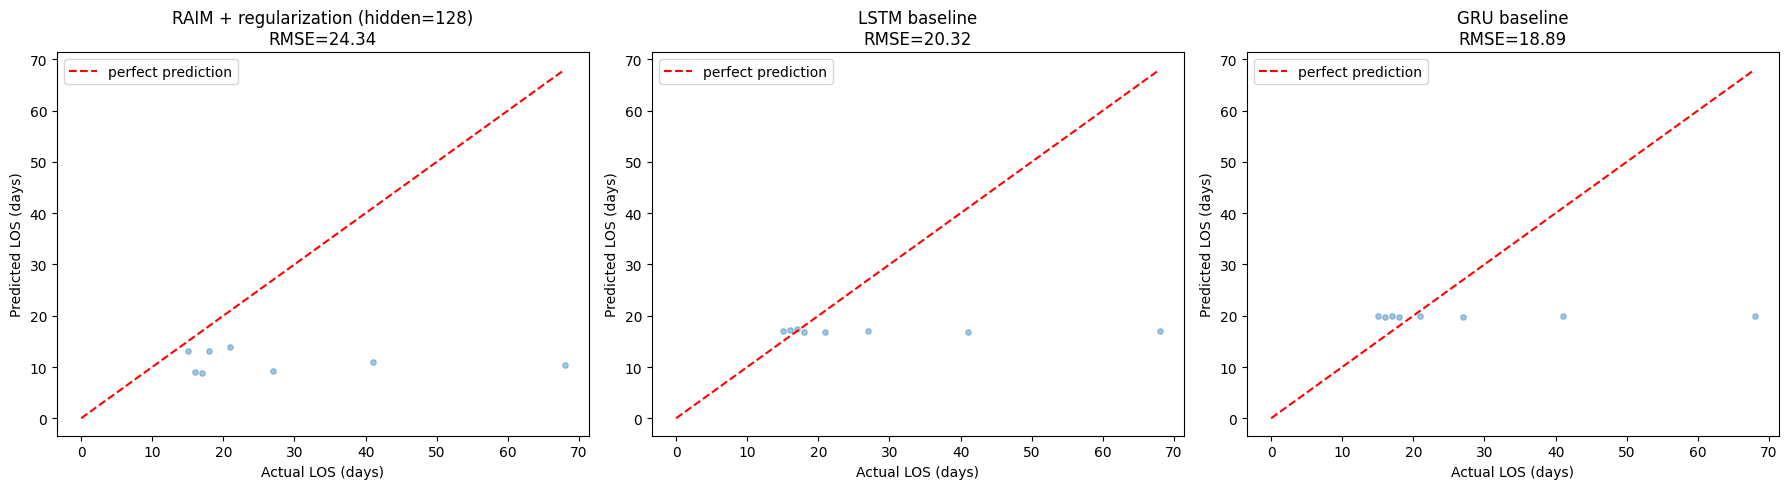

In [ ]:
# Cell 34: actual vs predicted for the winning regularized RAIM + both baselines, Case 3 config
true_reg, pred_reg = get_predictions(model_reg, val_loader_norm, device, threshold=None)
true_lstm, pred_lstm = get_predictions(model_lstm, val_loader, device, threshold=None)
true_gru, pred_gru = get_predictions(model_gru, val_loader, device, threshold=None)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (true, pred, title, rmse) in zip(axes, [
    (true_reg, pred_reg, "RAIM + regularization (hidden=128)", best_val_mse_reg**0.5),
    (true_lstm, pred_lstm, "LSTM baseline", best_val_mse_lstm**0.5),
    (true_gru, pred_gru, "GRU baseline", best_val_mse_gru**0.5),
]):
    ax.scatter(true, pred, alpha=0.4, s=15)
    lims = [0, max(true.max(), pred.max())]
    ax.plot(lims, lims, 'r--', label='perfect prediction')
    ax.set_title(f"{title}\nRMSE={rmse:.2f}")
    ax.set_xlabel("Actual LOS (days)")
    ax.set_ylabel("Predicted LOS (days)")
    ax.legend()

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/RAIM_Project_v2/regularized_vs_baselines_predicted.png', dpi=150)
plt.show()

In [ ]:
# Cell 35: quiet version of train_model_case_reg — same logic, no per-epoch prints,
# so a 36-combo grid search doesn't flood the output
def train_model_case_reg_quiet(model, train_loader, val_loader, max_epochs=100, patience=10, lr=1e-3,
                                weight_decay=1e-4, device='cpu', train_threshold=None, eval_threshold=None):
    model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    best_val_loss, best_state, epochs_no_improve = float('inf'), None, 0
    for epoch in range(1, max_epochs + 1):
        model.train()
        for xb, yb, lb in train_loader:
            xb, yb, lb = xb.to(device), yb.to(device), lb.to(device)
            optimizer.zero_grad()
            loss = masked_mse_filtered(model(xb, lb), yb, lb, threshold=train_threshold)
            loss.backward(); optimizer.step()
        model.eval()
        val_loss_sum, val_count = 0.0, 0
        with torch.no_grad():
            for xb, yb, lb in val_loader:
                xb, yb, lb = xb.to(device), yb.to(device), lb.to(device)
                loss = masked_mse_filtered(model(xb, lb), yb, lb, threshold=eval_threshold)
                val_loss_sum += loss.item() * xb.size(0); val_count += xb.size(0)
        val_mse = val_loss_sum / val_count
        if val_mse < best_val_loss:
            best_val_loss, best_state, epochs_no_improve = val_mse, {k: v.clone() for k, v in model.state_dict().items()}, 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                break
    model.load_state_dict(best_state)
    return model, best_val_loss

In [ ]:
# Cell 36: grid search over dropout / weight_decay / hidden_size, on normalized features
# (per Haimonti's request — the 0.3 / 1e-4 / 128 values need to be justified, not assumed)
import itertools
import pandas as pd

DROPOUT_GRID = [0.1, 0.3, 0.5]
WEIGHT_DECAY_GRID = [0.0, 1e-5, 1e-4, 1e-3]
HIDDEN_SIZE_GRID = [64, 128, 200]

SEARCH_MAX_EPOCHS = 50   # reduced budget for the search stage — winner gets a full retrain in Cell 38
SEARCH_PATIENCE = 7

grid_results = []

for dropout, weight_decay, hidden_size in itertools.product(DROPOUT_GRID, WEIGHT_DECAY_GRID, HIDDEN_SIZE_GRID):
    set_seed(42)
    model_grid = RAIMModelReg(input_dim=524, hidden_size=hidden_size, max_len=MAX_LEN, dropout=dropout)
    _, best_val_mse_grid = train_model_case_reg_quiet(
        model_grid, train_loader_norm, val_loader_norm,
        max_epochs=SEARCH_MAX_EPOCHS, patience=SEARCH_PATIENCE, lr=1e-3,
        weight_decay=weight_decay, device=device
    )
    rmse = best_val_mse_grid ** 0.5
    grid_results.append({"dropout": dropout, "weight_decay": weight_decay, "hidden_size": hidden_size, "val_rmse": rmse})
    print(f"dropout={dropout} weight_decay={weight_decay} hidden_size={hidden_size} -> val_rmse={rmse:.4f}")

dropout=0.1 weight_decay=0.0 hidden_size=64 -> val_rmse=29.3108
dropout=0.1 weight_decay=0.0 hidden_size=128 -> val_rmse=27.3248
dropout=0.1 weight_decay=0.0 hidden_size=200 -> val_rmse=25.7226
dropout=0.1 weight_decay=1e-05 hidden_size=64 -> val_rmse=29.3107
dropout=0.1 weight_decay=1e-05 hidden_size=128 -> val_rmse=27.3248
dropout=0.1 weight_decay=1e-05 hidden_size=200 -> val_rmse=25.7226
dropout=0.1 weight_decay=0.0001 hidden_size=64 -> val_rmse=29.3107
dropout=0.1 weight_decay=0.0001 hidden_size=128 -> val_rmse=27.3246
dropout=0.1 weight_decay=0.0001 hidden_size=200 -> val_rmse=25.7225
dropout=0.1 weight_decay=0.001 hidden_size=64 -> val_rmse=29.3100
dropout=0.1 weight_decay=0.001 hidden_size=128 -> val_rmse=27.3240
dropout=0.1 weight_decay=0.001 hidden_size=200 -> val_rmse=25.7220
dropout=0.3 weight_decay=0.0 hidden_size=64 -> val_rmse=29.4504
dropout=0.3 weight_decay=0.0 hidden_size=128 -> val_rmse=27.3498
dropout=0.3 weight_decay=0.0 hidden_size=200 -> val_rmse=25.8042
dropout=0

In [ ]:
# Cell 37: results table, sorted best-first
grid_df = pd.DataFrame(grid_results).sort_values("val_rmse").reset_index(drop=True)
grid_df.to_csv('/content/drive/MyDrive/RAIM_Project_v2/hyperparam_grid_search.csv', index=False)
grid_df

,dropout,weight_decay,hidden_size,val_rmse
0,0.1,0.00100,200,25.722022
1,0.1,0.00010,200,25.722530
2,0.1,0.00001,200,25.722562
3,0.1,0.00000,200,25.722567
4,0.3,0.00000,200,25.804237
5,0.3,0.00001,200,25.804238
6,0.3,0.00010,200,25.804360
7,0.3,0.00100,200,25.835532
8,0.5,0.00100,200,25.967650
9,0.5,0.00000,200,25.967797


In [ ]:
# Cell 38: full retrain of the winning combo at the standard 100-epoch/patience-10 budget,
# so this RMSE is directly comparable to the numbers in Cell 33's summary table
best_row = grid_df.iloc[0]
best_dropout, best_wd, best_hidden = float(best_row.dropout), float(best_row.weight_decay), int(best_row.hidden_size)

set_seed(42)
model_best = RAIMModelReg(input_dim=524, hidden_size=best_hidden, max_len=MAX_LEN, dropout=best_dropout)
model_best, history_best, best_val_mse_final = train_model_case_reg(
    model_best, train_loader_norm, val_loader_norm, max_epochs=100, patience=10, lr=1e-3,
    weight_decay=best_wd, device=device
)
print(f"[Grid-search winner: dropout={best_dropout}, weight_decay={best_wd}, hidden_size={best_hidden}]")
print(f"best val RMSE: {best_val_mse_final**0.5:.4f}")

epoch 1: train_mse=586.6950 val_mse=1067.8591 val_rmse=32.6781
epoch 2: train_mse=569.7070 val_mse=1052.9098 val_rmse=32.4486
epoch 3: train_mse=554.2322 val_mse=1038.6211 val_rmse=32.2276
epoch 4: train_mse=539.4371 val_mse=1024.3364 val_rmse=32.0053
epoch 5: train_mse=523.7281 val_mse=1009.8989 val_rmse=31.7789
epoch 6: train_mse=510.8946 val_mse=995.3818 val_rmse=31.5497
epoch 7: train_mse=498.1179 val_mse=981.0725 val_rmse=31.3221
epoch 8: train_mse=484.0396 val_mse=967.3163 val_rmse=31.1017
epoch 9: train_mse=471.7841 val_mse=954.3001 val_rmse=30.8917
epoch 10: train_mse=462.2987 val_mse=942.0544 val_rmse=30.6929
epoch 11: train_mse=450.4807 val_mse=930.5585 val_rmse=30.5051
epoch 12: train_mse=440.1848 val_mse=919.6962 val_rmse=30.3265
epoch 13: train_mse=430.4350 val_mse=909.3284 val_rmse=30.1551
epoch 14: train_mse=421.4543 val_mse=899.4138 val_rmse=29.9902
epoch 15: train_mse=410.8956 val_mse=889.9019 val_rmse=29.8312
epoch 16: train_mse=405.3723 val_mse=880.7477 val_rmse=29.6

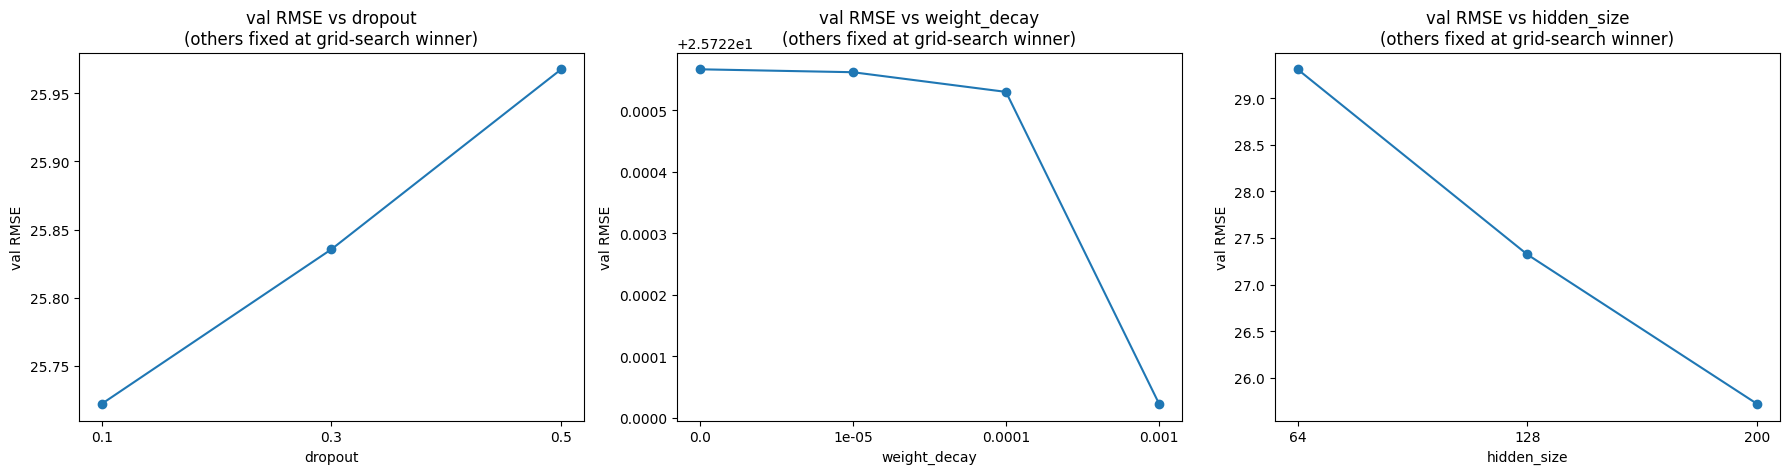

In [ ]:
# Cell 39: RMSE vs each hyperparameter, holding the other two at the winning values — for the paper
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, param in zip(axes, ["dropout", "weight_decay", "hidden_size"]):
    others = [p for p in ["dropout", "weight_decay", "hidden_size"] if p != param]
    fixed = grid_df[(grid_df[others[0]] == best_row[others[0]]) & (grid_df[others[1]] == best_row[others[1]])]
    fixed = fixed.sort_values(param)
    ax.plot(fixed[param].astype(str), fixed["val_rmse"], marker='o')
    ax.set_title(f"val RMSE vs {param}\n(others fixed at grid-search winner)")
    ax.set_xlabel(param)
    ax.set_ylabel("val RMSE")

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/RAIM_Project_v2/hyperparam_sensitivity.png', dpi=150)
plt.show()

In [ ]:
# Cell 40: regularized RAIM on Case 1 (PLOS-only: train+eval only on long-LOS encounters)
set_seed(42)
model_reg_case1 = RAIMModelReg(input_dim=524, hidden_size=128, max_len=MAX_LEN, dropout=0.3)
model_reg_case1, history_reg_case1, best_val_mse_reg_case1 = train_model_case_reg(
    model_reg_case1, train_loader_norm, val_loader_norm, max_epochs=100, patience=10, lr=1e-3,
    weight_decay=1e-4, device=device, train_threshold=LLOS_THRESHOLD, eval_threshold=LLOS_THRESHOLD
)
print(f"[RAIM + regularization, Case 1] best val RMSE: {best_val_mse_reg_case1**0.5:.4f}")

epoch 1: train_mse=581.0284 val_mse=1066.0363 val_rmse=32.6502
epoch 2: train_mse=569.5879 val_mse=1054.3312 val_rmse=32.4705
epoch 3: train_mse=555.8964 val_mse=1042.6627 val_rmse=32.2903
epoch 4: train_mse=544.7936 val_mse=1030.7157 val_rmse=32.1048
epoch 5: train_mse=532.1306 val_mse=1018.7349 val_rmse=31.9176
epoch 6: train_mse=522.1035 val_mse=1006.8201 val_rmse=31.7304
epoch 7: train_mse=511.0508 val_mse=995.1323 val_rmse=31.5457
epoch 8: train_mse=501.9756 val_mse=983.8430 val_rmse=31.3663
epoch 9: train_mse=493.4623 val_mse=973.1010 val_rmse=31.1946
epoch 10: train_mse=479.9875 val_mse=962.8483 val_rmse=31.0298
epoch 11: train_mse=470.6335 val_mse=953.2040 val_rmse=30.8740
epoch 12: train_mse=465.0711 val_mse=944.1469 val_rmse=30.7270
epoch 13: train_mse=458.1902 val_mse=935.5377 val_rmse=30.5866
epoch 14: train_mse=450.2759 val_mse=927.4128 val_rmse=30.4535
epoch 15: train_mse=445.5491 val_mse=919.7455 val_rmse=30.3273
epoch 16: train_mse=437.4201 val_mse=912.4688 val_rmse=30.

In [ ]:
# Cell 41: LSTM and GRU baselines on Case 1, same threshold filtering
model_lstm_case1 = LSTMBaseline(input_dim=524, hidden_size=200)
model_lstm_case1, history_lstm_case1, best_val_mse_lstm_case1 = train_model_case(
    model_lstm_case1, train_loader, val_loader, max_epochs=100, patience=10, lr=1e-3,
    device=device, train_threshold=LLOS_THRESHOLD, eval_threshold=LLOS_THRESHOLD
)
print(f"[LSTM baseline, Case 1] best val RMSE: {best_val_mse_lstm_case1**0.5:.4f}")

model_gru_case1 = GRUBaseline(input_dim=524, hidden_size=200)
model_gru_case1, history_gru_case1, best_val_mse_gru_case1 = train_model_case(
    model_gru_case1, train_loader, val_loader, max_epochs=100, patience=10, lr=1e-3,
    device=device, train_threshold=LLOS_THRESHOLD, eval_threshold=LLOS_THRESHOLD
)
print(f"[GRU baseline, Case 1] best val RMSE: {best_val_mse_gru_case1**0.5:.4f}")

epoch 1: train_mse=576.5290 val_mse=1054.9705 val_rmse=32.4803
epoch 2: train_mse=571.6738 val_mse=1049.1663 val_rmse=32.3908
epoch 3: train_mse=566.8276 val_mse=1043.3805 val_rmse=32.3014
epoch 4: train_mse=561.9962 val_mse=1037.6257 val_rmse=32.2122
epoch 5: train_mse=557.1866 val_mse=1031.9127 val_rmse=32.1234
epoch 6: train_mse=552.4029 val_mse=1026.2426 val_rmse=32.0350
epoch 7: train_mse=547.6431 val_mse=1020.6014 val_rmse=31.9469
epoch 8: train_mse=542.8994 val_mse=1014.9622 val_rmse=31.8585
epoch 9: train_mse=538.1606 val_mse=1009.2933 val_rmse=31.7694
epoch 10: train_mse=533.4144 val_mse=1003.5640 val_rmse=31.6791
epoch 11: train_mse=528.6489 val_mse=997.7493 val_rmse=31.5872
epoch 12: train_mse=523.8527 val_mse=991.8283 val_rmse=31.4933
epoch 13: train_mse=519.0156 val_mse=985.7841 val_rmse=31.3972
epoch 14: train_mse=514.1270 val_mse=979.6037 val_rmse=31.2986
epoch 15: train_mse=509.1754 val_mse=973.2792 val_rmse=31.1974
epoch 16: train_mse=504.1486 val_mse=966.8069 val_rmse

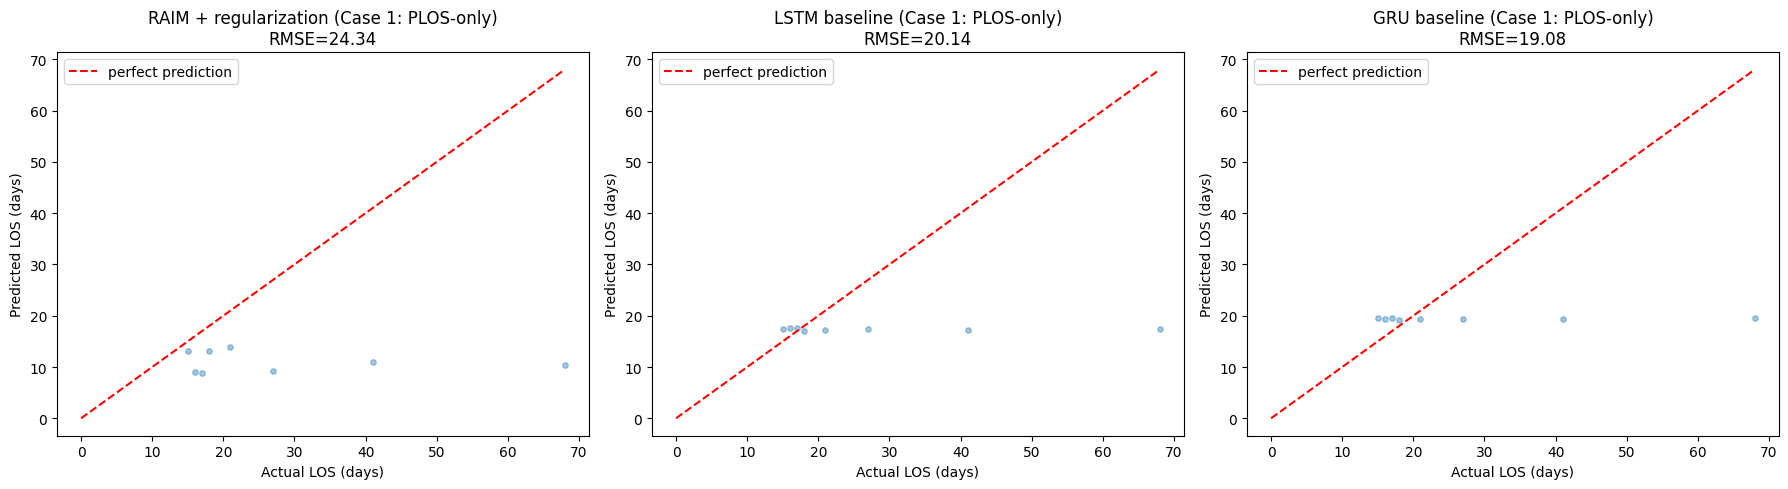

In [ ]:
# Cell 42: actual vs predicted, Case 1 (PLOS-only) — regularized RAIM + both baselines
true_reg1, pred_reg1 = get_predictions(model_reg_case1, val_loader_norm, device, threshold=LLOS_THRESHOLD)
true_lstm1, pred_lstm1 = get_predictions(model_lstm_case1, val_loader, device, threshold=LLOS_THRESHOLD)
true_gru1, pred_gru1 = get_predictions(model_gru_case1, val_loader, device, threshold=LLOS_THRESHOLD)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (true, pred, title, rmse) in zip(axes, [
    (true_reg1, pred_reg1, "RAIM + regularization (Case 1: PLOS-only)", best_val_mse_reg_case1**0.5),
    (true_lstm1, pred_lstm1, "LSTM baseline (Case 1: PLOS-only)", best_val_mse_lstm_case1**0.5),
    (true_gru1, pred_gru1, "GRU baseline (Case 1: PLOS-only)", best_val_mse_gru_case1**0.5),
]):
    ax.scatter(true, pred, alpha=0.4, s=15)
    lims = [0, max(true.max(), pred.max())]
    ax.plot(lims, lims, 'r--', label='perfect prediction')
    ax.set_title(f"{title}\nRMSE={rmse:.2f}")
    ax.set_xlabel("Actual LOS (days)")
    ax.set_ylabel("Predicted LOS (days)")
    ax.legend()

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/RAIM_Project_v2/case1_plos_only_predicted.png', dpi=150)
plt.show()

In [ ]:
# Cell 43: regularized RAIM on Case 2 (train on everything, eval only on long-LOS)
set_seed(42)
model_reg_case2 = RAIMModelReg(input_dim=524, hidden_size=128, max_len=MAX_LEN, dropout=0.3)
model_reg_case2, history_reg_case2, best_val_mse_reg_case2 = train_model_case_reg(
    model_reg_case2, train_loader_norm, val_loader_norm, max_epochs=100, patience=10, lr=1e-3,
    weight_decay=1e-4, device=device, train_threshold=None, eval_threshold=LLOS_THRESHOLD
)
print(f"[RAIM + regularization, Case 2] best val RMSE: {best_val_mse_reg_case2**0.5:.4f}")

epoch 1: train_mse=581.0284 val_mse=1066.0363 val_rmse=32.6502
epoch 2: train_mse=569.5879 val_mse=1054.3312 val_rmse=32.4705
epoch 3: train_mse=555.8964 val_mse=1042.6627 val_rmse=32.2903
epoch 4: train_mse=544.7936 val_mse=1030.7157 val_rmse=32.1048
epoch 5: train_mse=532.1306 val_mse=1018.7349 val_rmse=31.9176
epoch 6: train_mse=522.1035 val_mse=1006.8201 val_rmse=31.7304
epoch 7: train_mse=511.0508 val_mse=995.1323 val_rmse=31.5457
epoch 8: train_mse=501.9756 val_mse=983.8430 val_rmse=31.3663
epoch 9: train_mse=493.4623 val_mse=973.1010 val_rmse=31.1946
epoch 10: train_mse=479.9875 val_mse=962.8483 val_rmse=31.0298
epoch 11: train_mse=470.6335 val_mse=953.2040 val_rmse=30.8740
epoch 12: train_mse=465.0711 val_mse=944.1469 val_rmse=30.7270
epoch 13: train_mse=458.1902 val_mse=935.5377 val_rmse=30.5866
epoch 14: train_mse=450.2759 val_mse=927.4128 val_rmse=30.4535
epoch 15: train_mse=445.5491 val_mse=919.7455 val_rmse=30.3273
epoch 16: train_mse=437.4201 val_mse=912.4688 val_rmse=30.

In [ ]:
# Cell 44: LSTM and GRU baselines on Case 2
model_lstm_case2 = LSTMBaseline(input_dim=524, hidden_size=200)
model_lstm_case2, history_lstm_case2, best_val_mse_lstm_case2 = train_model_case(
    model_lstm_case2, train_loader, val_loader, max_epochs=100, patience=10, lr=1e-3,
    device=device, train_threshold=None, eval_threshold=LLOS_THRESHOLD
)
print(f"[LSTM baseline, Case 2] best val RMSE: {best_val_mse_lstm_case2**0.5:.4f}")

model_gru_case2 = GRUBaseline(input_dim=524, hidden_size=200)
model_gru_case2, history_gru_case2, best_val_mse_gru_case2 = train_model_case(
    model_gru_case2, train_loader, val_loader, max_epochs=100, patience=10, lr=1e-3,
    device=device, train_threshold=None, eval_threshold=LLOS_THRESHOLD
)
print(f"[GRU baseline, Case 2] best val RMSE: {best_val_mse_gru_case2**0.5:.4f}")

epoch 1: train_mse=576.5290 val_mse=1054.9705 val_rmse=32.4803
epoch 2: train_mse=571.6738 val_mse=1049.1663 val_rmse=32.3908
epoch 3: train_mse=566.8276 val_mse=1043.3805 val_rmse=32.3014
epoch 4: train_mse=561.9962 val_mse=1037.6257 val_rmse=32.2122
epoch 5: train_mse=557.1866 val_mse=1031.9127 val_rmse=32.1234
epoch 6: train_mse=552.4029 val_mse=1026.2426 val_rmse=32.0350
epoch 7: train_mse=547.6431 val_mse=1020.6014 val_rmse=31.9469
epoch 8: train_mse=542.8994 val_mse=1014.9622 val_rmse=31.8585
epoch 9: train_mse=538.1606 val_mse=1009.2933 val_rmse=31.7694
epoch 10: train_mse=533.4144 val_mse=1003.5640 val_rmse=31.6791
epoch 11: train_mse=528.6489 val_mse=997.7493 val_rmse=31.5872
epoch 12: train_mse=523.8527 val_mse=991.8283 val_rmse=31.4933
epoch 13: train_mse=519.0156 val_mse=985.7841 val_rmse=31.3972
epoch 14: train_mse=514.1270 val_mse=979.6037 val_rmse=31.2986
epoch 15: train_mse=509.1754 val_mse=973.2792 val_rmse=31.1974
epoch 16: train_mse=504.1486 val_mse=966.8069 val_rmse

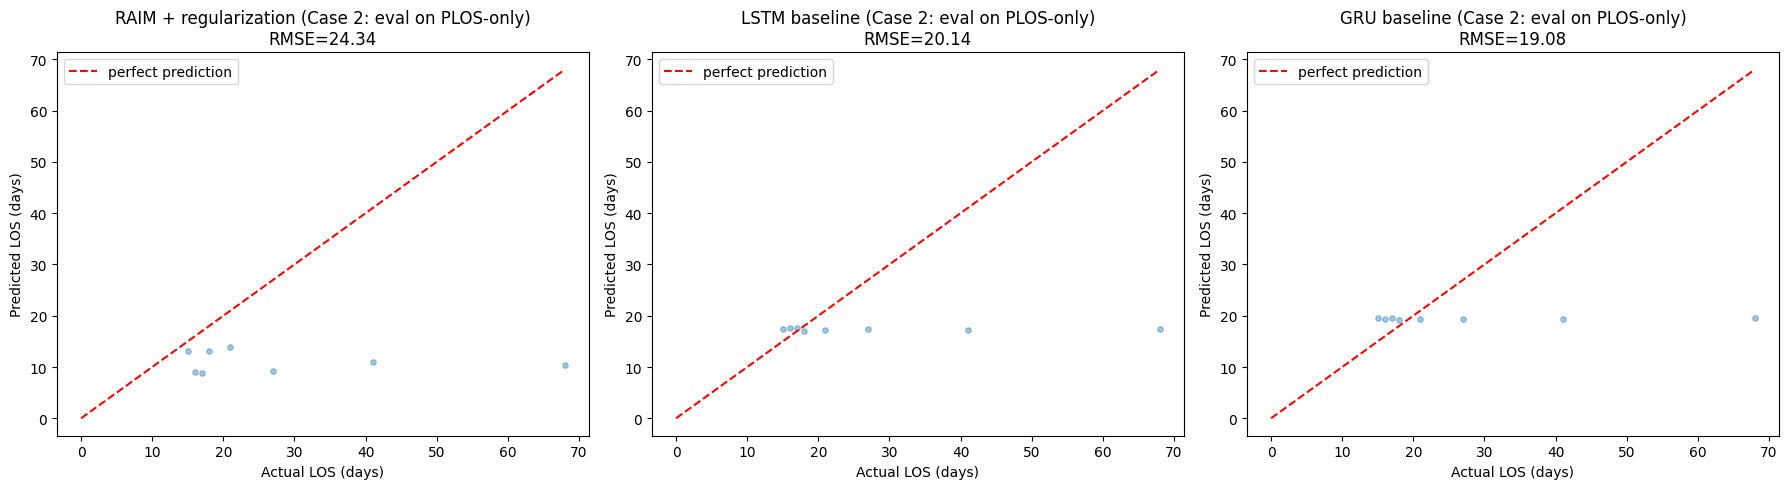

In [ ]:
# Cell 45: actual vs predicted, Case 2 (trained on everything, evaluated on PLOS-only)
true_reg2, pred_reg2 = get_predictions(model_reg_case2, val_loader_norm, device, threshold=LLOS_THRESHOLD)
true_lstm2, pred_lstm2 = get_predictions(model_lstm_case2, val_loader, device, threshold=LLOS_THRESHOLD)
true_gru2, pred_gru2 = get_predictions(model_gru_case2, val_loader, device, threshold=LLOS_THRESHOLD)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (true, pred, title, rmse) in zip(axes, [
    (true_reg2, pred_reg2, "RAIM + regularization (Case 2: eval on PLOS-only)", best_val_mse_reg_case2**0.5),
    (true_lstm2, pred_lstm2, "LSTM baseline (Case 2: eval on PLOS-only)", best_val_mse_lstm_case2**0.5),
    (true_gru2, pred_gru2, "GRU baseline (Case 2: eval on PLOS-only)", best_val_mse_gru_case2**0.5),
]):
    ax.scatter(true, pred, alpha=0.4, s=15)
    lims = [0, max(true.max(), pred.max())]
    ax.plot(lims, lims, 'r--', label='perfect prediction')
    ax.set_title(f"{title}\nRMSE={rmse:.2f}")
    ax.set_xlabel("Actual LOS (days)")
    ax.set_ylabel("Predicted LOS (days)")
    ax.legend()

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/RAIM_Project_v2/case2_plos_eval_predicted.png', dpi=150)
plt.show()

In [ ]:
# Cell 46: flatten padded sequences into an encounter-level table for the Random Forest,
# masking out padding using `lengths`, and splitting by the same train_idx/val_idx patients
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

def flatten_encounters(patient_indices):
    X_list, y_list = [], []
    for pi in patient_indices:
        n = lengths[pi]
        X_list.append(X_padded[pi, :n, :])
        y_list.append(Y_padded[pi, :n])
    return np.concatenate(X_list, axis=0), np.concatenate(y_list, axis=0)

X_train_flat, y_train_flat = flatten_encounters(train_idx)
X_val_flat, y_val_flat = flatten_encounters(val_idx)

print(f"train encounters: {X_train_flat.shape[0]}, val encounters: {X_val_flat.shape[0]}")

train encounters: 28, val encounters: 8


In [ ]:
# Cell 47: train Random Forest, get overall + PLOS-subset RMSE, and global feature importance by block
rf = RandomForestRegressor(n_estimators=300, max_depth=None, min_samples_leaf=2,
                            random_state=42, n_jobs=-1)
rf.fit(X_train_flat, y_train_flat)

pred_val = rf.predict(X_val_flat)
rmse_all = mean_squared_error(y_val_flat, pred_val) ** 0.5

plos_mask = y_val_flat > LLOS_THRESHOLD
rmse_plos = mean_squared_error(y_val_flat[plos_mask], pred_val[plos_mask]) ** 0.5

print(f"RF val RMSE (all encounters): {rmse_all:.4f}")
print(f"RF val RMSE (PLOS-only, n={plos_mask.sum()}): {rmse_plos:.4f}")

# feature blocks, per Section 5.7: 10 demo/vitals, 4x128 embeddings, 2 flags
blocks = {
    "Demographics + Vitals (0-9)": (0, 10),
    "Condition embedding (10-137)": (10, 138),
    "Procedure embedding (138-265)": (138, 266),
    "Notes embedding (266-393)": (266, 394),
    "Medication embedding (394-521)": (394, 522),
    "Lab + medication flags (522-523)": (522, 524),
}

block_importance = {name: rf.feature_importances_[start:end].sum() for name, (start, end) in blocks.items()}
for name, imp in sorted(block_importance.items(), key=lambda x: -x[1]):
    print(f"{name}: {imp:.4f}")

RF val RMSE (all encounters): 14.9889
RF val RMSE (PLOS-only, n=8): 14.9889
Notes embedding (266-393): 0.7297
Procedure embedding (138-265): 0.1900
Condition embedding (10-137): 0.0599
Medication embedding (394-521): 0.0122
Demographics + Vitals (0-9): 0.0082
Lab + medication flags (522-523): 0.0000


Procedure embedding (138-265): 1.2271
Notes embedding (266-393): 1.0899
Condition embedding (10-137): 0.1279
Medication embedding (394-521): 0.0304
Demographics + Vitals (0-9): 0.0198
Lab + medication flags (522-523): 0.0000


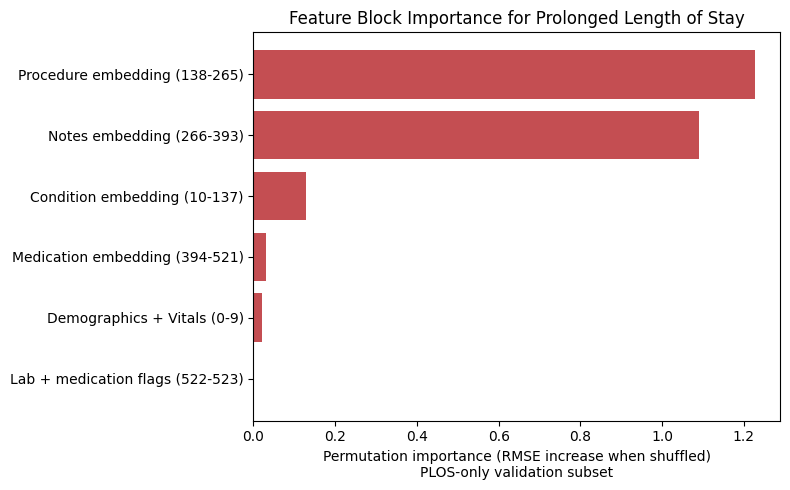

In [ ]:
# Cell 48: permutation importance computed specifically on the PLOS-only validation subset —
# this shows what drives variance within long stays, not overall, which is the actual question
from sklearn.inspection import permutation_importance

X_val_plos = X_val_flat[plos_mask]
y_val_plos = y_val_flat[plos_mask]

perm_result = permutation_importance(rf, X_val_plos, y_val_plos, n_repeats=20,
                                      random_state=42, n_jobs=-1, scoring='neg_root_mean_squared_error')

block_perm_importance = {name: perm_result.importances_mean[start:end].sum() for name, (start, end) in blocks.items()}
for name, imp in sorted(block_perm_importance.items(), key=lambda x: -x[1]):
    print(f"{name}: {imp:.4f}")

fig, ax = plt.subplots(figsize=(8, 5))
names_sorted = sorted(block_perm_importance, key=lambda k: block_perm_importance[k])
ax.barh(names_sorted, [block_perm_importance[n] for n in names_sorted], color='#C44E52')
ax.set_xlabel("Permutation importance (RMSE increase when shuffled)\nPLOS-only validation subset")
ax.set_title("Feature Block Importance for Prolonged Length of Stay")
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/RAIM_Project_v2/plos_feature_importance.png', dpi=200)
plt.show()